##### `Stape 1 : Prepare The Data`

In [1]:
"""IMPORT EVERYTHING.. """
# Data manipulation
import pandas as pd
import numpy as np

# Quantitative analysis / indicators
import talib
import backtrader as bt

# # Machine learning / statistics
# import scipy
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns
import mplfinance as mpf

# # Jupyter Notebook magic for inline plots
# %matplotlib inline


In [2]:
"""Load Source OHLCV dta"""

df = pd.read_parquet("../Src/filtered.XAUUSD-M1.parquet", engine="pyarrow")

# print(df.head(3))

In [3]:
lorem = df.copy()

addplot = []

periods = [21, 51,151,251,300,400,500,700,900]  # 21 to 30, adjust as needed

for p in periods:
    lorem[f'EMA_{p}'] = talib.EMA(df['CLOSE'], timeperiod=p)
    lorem[f'WMA_{p}'] = talib.WMA(df['CLOSE'], timeperiod=p)


In [4]:
"""rename Clmns """
lorem.rename(columns={
    'OPEN': 'open',
    'HIGH': 'high',
    'LOW': 'low',
    'CLOSE': 'close',
    'VOL': 'volume'
}, inplace=True)

##### `Stape 2: Resampling Data & Cahrt Visualisation`

In [5]:
"""ReSample data for Better Visualisation and minimize Calculaion"""
from resampler import OHLCVResampler

# Resample to 1 hour - all columns preserved
resampler = OHLCVResampler(default_agg='last')

result = resampler.resample(lorem, '1min', '2024-11-01', '2024-11-02')

print(f"\nResampled shape: {result.shape}")

# result


Resampled shape: (1258, 23)


In [6]:
"""Setting Chart Configs"""
from ChartterX5 import Chartter

chartter = Chartter(config={
    'chart_type': 'candle',
    'style': 'charles',
    'volume': False
})

chartter._setup_tradingview_theme()

cnf = {
        'title': 'NONE',
        'style': chartter.tradingview_style,
        'volume': False,
        'show_nontrading': False,
        'datetime_format': '%Y-%m-%d',
        'xlabel': '',
        'ylabel': '',
        'xrotation': 0
    }
# result.head(3)

2025-10-17 07:42:45,394 [INFO] Generating chart da88b0d6-3ecc-4d2b-82bb-7734b196c8e1 with 1258 data points
2025-10-17 07:42:46,193 [INFO] Chart da88b0d6-3ecc-4d2b-82bb-7734b196c8e1 generated successfully in 0.80s


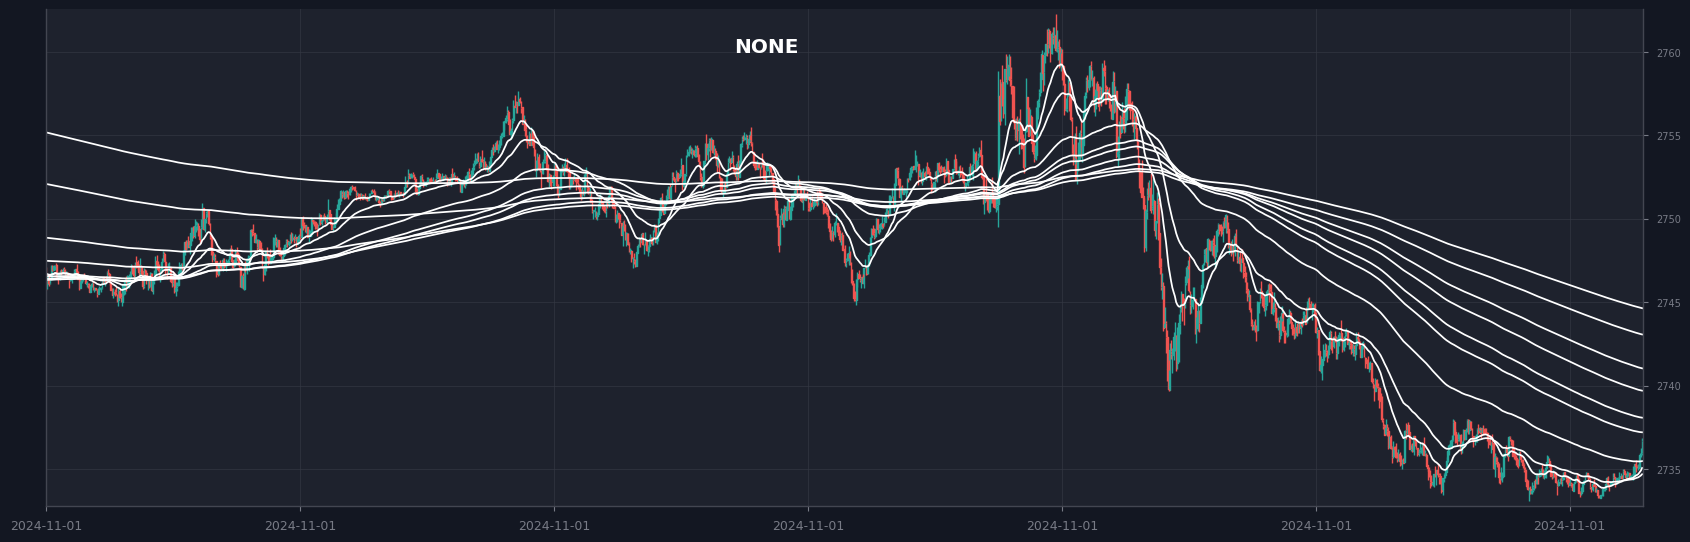

In [7]:
"""Creating The Main Chart"""

fig, axes =chartter.plot(
    result,
    addplot=[
        mpf.make_addplot(result['EMA_21'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_51'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_151'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_251'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_300'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_400'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_500'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_700'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['EMA_900'], panel=0, color='white', ylabel='RSI'),
    ],
    config=cnf,
    returnfig=True
)

2025-10-17 07:42:47,797 [INFO] Generating chart 6d112384-99b5-4fcd-8745-7fbd7d166d2c with 1258 data points
2025-10-17 07:42:48,166 [INFO] Chart 6d112384-99b5-4fcd-8745-7fbd7d166d2c generated successfully in 0.37s


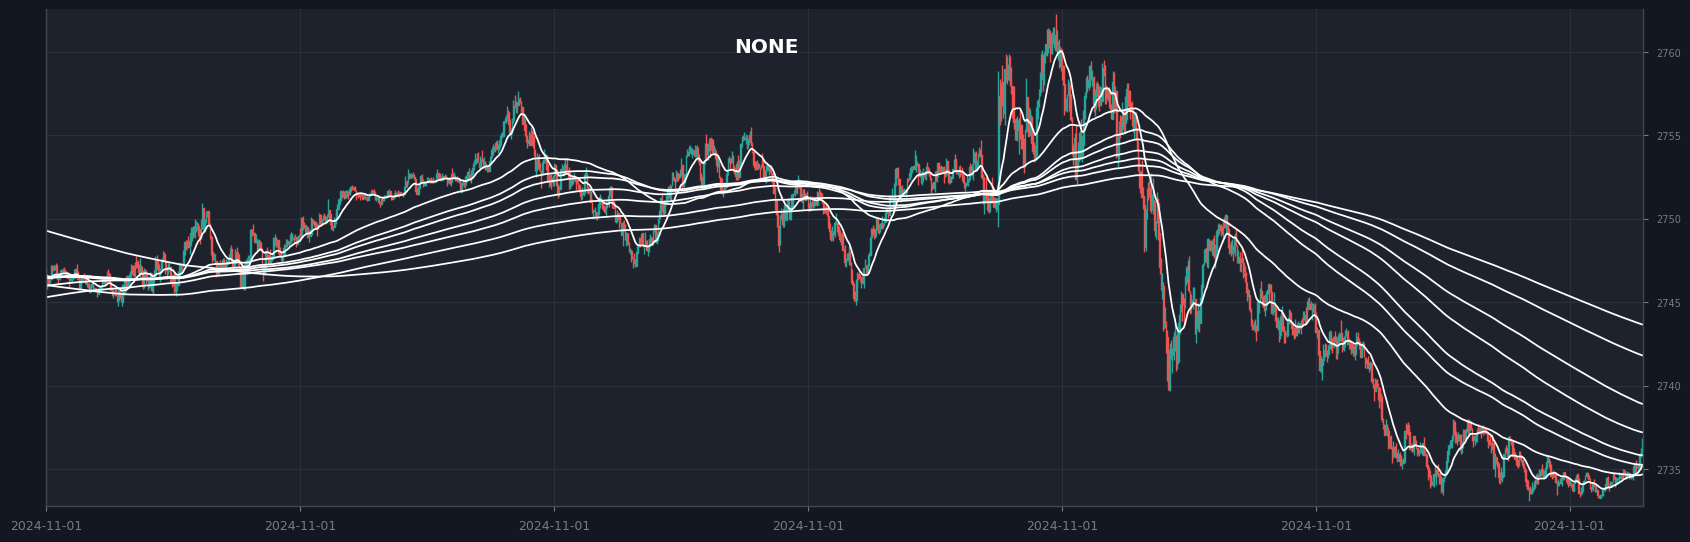

In [8]:
"""Creating The Main Chart"""

fig, axes =chartter.plot(
    result,
    addplot=[
        mpf.make_addplot(result['WMA_21'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_151'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_251'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_300'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_400'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_500'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_700'], panel=0, color='white', ylabel='RSI'),
        mpf.make_addplot(result['WMA_900'], panel=0, color='white', ylabel='RSI'),
    ],
    config=cnf,
    returnfig=True
)